In [9]:
import geopandas as gpd
import pandas as pd

# 0) Read once
g = gpd.read_file("../Data/Shapefiles/APES_metric.gpkg", layer="nuts3")

# 1) Build the *universe* of NUTS codes with a single geometry per code
#    (dissolve merges duplicate rows per code; keeps geometry non-empty)
g_universe = (
    g.loc[~g.geometry.is_empty, ['NUTS_CODE', 'geometry']]
      .dissolve(by='NUTS_CODE', as_index=False)
)

print("Universe NUTS:", g_universe.shape[0])  # ~1460

# 2) Apply your content filter (but do it on a copy)
g_filt = g.loc[(~g.geometry.is_empty) & (g["RecordType"] != "ZIKV")].copy()

# Which NUTS got lost by the filter?
lost_codes = sorted(set(g_universe['NUTS_CODE']) - set(g_filt['NUTS_CODE']))
print("Lost NUTS codes:", len(lost_codes))

# Peek the lost geometries (map or table)
lost_geo = g_universe[g_universe['NUTS_CODE'].isin(lost_codes)]
# lost_geo.plot()   # uncomment to visualize

# 3) Aggregate your filtered attributes by NUTS (EDIT value_cols as needed)
# Example: suppose you want counts by NUTS or sums/means of certain columns
covariates = ["Forest", "Shrub", "Urban", "Crop", "Water", "Other",
           "Mean_P_Winter", "Max_WD_Winter", "Max_DD_Winter",
           "Mean_T_Spring", "Max_DD_Spring",
           "Mean_T_Summer",
           "Max_WD_Autumn", "Max_DD_Autumn",
           "gdp", "pop_dens"]

value_cols = ['incidence']+covariates  # <-- replace with your actual columns to carry over
agg = (g_filt.groupby('NUTS_CODE')[value_cols]
              .sum()                      # or .mean(), .first(), etc.
              .reset_index())

# 4) Left-join back onto the full universe and fill missing with 0
g_out = g_universe.merge(agg, on='NUTS_CODE', how='left')
g_out[value_cols] = g_out[value_cols].fillna(0)

print("Final rows (keeps all NUTS):", len(g_out))
print(g_out[[ 'NUTS_CODE'] + value_cols].head())

# 5) (Optional) write out
# g_out.to_file("nuts3_full_with_metrics.gpkg", layer="table1_ready", driver="GPKG")


Universe NUTS: 1174
Lost NUTS codes: 0
Final rows (keeps all NUTS): 1174
  NUTS_CODE  incidence        Forest        Shrub        Urban          Crop  \
0     AL011   0.000000  29792.285714  2233.142857  1685.000000  23692.857143   
1     AL012   0.000000   2486.428571   167.142857   734.571429   7191.714286   
2     AL014   0.000000  12931.857143   681.928571   595.428571   8346.642857   
3     AL015   0.000073  49866.230769  3503.769231  3389.230769  30132.230769   
4     AL021   0.000000  40329.357143  2462.285714  1559.285714  44483.571429   

         Water         Other  Mean_P_Winter  Max_WD_Winter  Max_DD_Winter  \
0   684.214286  10276.500000       0.004791       9.928571      10.428571   
1   111.000000     56.142857       0.004986       9.500000      11.500000   
2   360.214286    400.928571       0.004907       9.142857      10.857143   
3  5994.692308   6761.846154       0.017661      21.846154      20.769231   
4   238.571429   6374.928571       0.003791       8.285714   

In [10]:
import numpy as np

cols_keep = (["incidence"] + covariates + ["geometry", "NUTS_NAME", "NUTS_CODE"])
gdf = gpd.GeoDataFrame(g_out)
gdf = gdf.to_crs(32633)
coords = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])

In [14]:
from sklearn.preprocessing import StandardScaler
from spreg import OLS  # pip install pysal spreg
from libpysal.weights import DistanceBand, lag_spatial, KNN
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR
import statsmodels.api as sm

scaler = StandardScaler()
X_std = scaler.fit_transform(gdf[covariates].to_numpy())
print(f'Dimension of Matrix X of the covariates is {np.shape(X_std)}')

y_raw = gdf['incidence'].to_numpy().reshape(-1, 1)  # column vector


Dimension of Matrix X of the covariates is (1174, 16)


In [15]:
d = 150000
W = DistanceBand(coords, threshold=d, binary=True, silence_warnings=True)
W.transform = "R"
# --- Spatial lag then standardize y ---
y_lag = lag_spatial(W, y_raw.ravel()).reshape(-1, 1)
Wy_z = (y_lag - y_lag.mean(axis=0)) / y_lag.std(axis=0, ddof=0)

# --- OLS (global) ---
y_sm = Wy_z.ravel()                               # 1D endog for sm.OLS
X_df = pd.DataFrame(X_std, columns=covariates)
# Add intercept column
X_df = sm.add_constant(X_df)
ols_sm = sm.OLS(y_sm, X_df).fit()  # classical OLS

In [16]:
ols_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.458
Method:                 Least Squares   F-statistic:                     63.01
Date:                Mon, 10 Nov 2025   Prob (F-statistic):          7.93e-145
Time:                        14:17:09   Log-Likelihood:                -1298.0
No. Observations:                1174   AIC:                             2630.
Df Residuals:                    1157   BIC:                             2716.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -6.782e-17      0.021  -3.16e-15      1.000      -0.042       0.042
Forest           -0.0680      0.030     -2.302      0.022      -0.126      -0.010
Shrub             0.1960      0.025      7.715      0.000       0.146       0.246
Urban            -0.0725      0.027     -2.677      0.008      -0.126      -0.019
Crop             -0.1159      0.032     -3.604      0.000      -0.179      -0.053
Water             0.0396      0.024      1.656      0.098      -0.007       0.087
Other             0.0032      0.026      0.122      0.903      -0.048       0.055
Mean_P_Winter    -0.1365      0.045     -3.047      0.002      -0.224      -0.049
Max_WD_Winter    -0.0540      0.049     -1.108      0.268      -0.150       0.042
Max_DD_Winter    -0.3648      0.070     -5.204      0.000      -0.502      -0.227
Mean_T_Spring    -2.7179      0.259    -10.507      0.000      -3.225      -2.210
Max_DD_Spring    -0.5318      0.042    -12.630      0.000      -0.614      -0.449
Mean_T_Summer     4.1123      0.295     13.958      0.000       3.534       4.690
Max_WD_Autumn     0.0163      0.041      0.400      0.689      -0.064       0.096
Max_DD_Autumn     0.0250      0.071      0.354      0.724      -0.114       0.163
gdp              -0.0406      0.027     -1.484      0.138      -0.094       0.013
pop_dens          0.0337      0.025      1.361      0.174      -0.015       0.082
==============================================================================
Omnibus:                     1119.565   Durbin-Watson:                   0.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            75154.040
Skew:                           4.240   Prob(JB):                         0.00
Kurtosis:                      41.268   Cond. No.                         45.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [17]:
bw = Sel_BW(coords, Wy_z, X_std, kernel="exponential", fixed=False).search()
gwr_fit = GWR(coords, Wy_z, X_std, bw, kernel="exponential", name_x=covariates, fixed=False, constant=True).fit()
gwr_fit.summary()

Model type                                                         Gaussian
Number of observations:                                                1174
Number of covariates:                                                    17

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            627.364
Log-likelihood:                                                   -1297.993
AIC:                                                               2629.987
AICc:                                                              2632.579
BIC:                                                              -7550.511
R2:                                                                   0.466
Adj. R2:                                                              0.458

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

In [18]:
gdf['localR2'] = gwr_fit.localR2

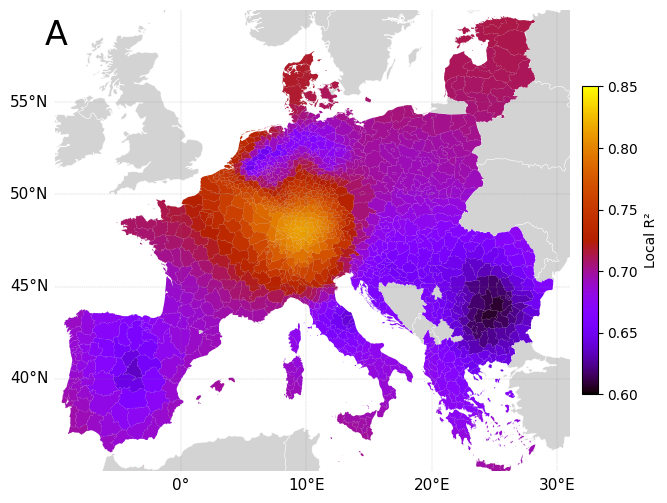

In [52]:
import pylab as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# --- Projection ---
proj = ccrs.PlateCarree()  # simple lat/lon projection

gdfcrs = gdf.to_crs("EPSG:4326")
url = "../Data/Shapefiles/world-administrative-boundaries.zip"
world = gpd.read_file(url)


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj})
world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=0)
gdfcrs.plot(ax=ax,  column='localR2',cmap='gnuplot', legend=True, linewidth=0.02, zorder=1, vmin=0.6, vmax=0.85,    
        legend_kwds={
        'shrink': 0.5,        # reduces height to 50%
        'aspect': 20,         # make bar thinner/wider
        'pad': 0.02,          # spacing from map
        'label': 'Local R²'   # colorbar label
    })

# --- Style ---
ax.set_axis_off()
ax.set_xlim(-10, 31)
ax.set_ylim(35, 60)

ax.text(
    -0.02, 0.98,                      # (x, y) position in axes fraction (0–1)
    "A",           # your text
    transform=ax.transAxes,          # interpret coords in axes space, not data
    fontsize=24,
    color='black',
    ha='left', va='top',             # align relative to position
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
)


# --- Add Cartopy gridlines ---
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

In [53]:
fig.savefig('../Figures/Figure2A.png', dpi=300, bbox_inches='tight')
fig.savefig('../Figures/Figure2A.pdf', dpi=300, bbox_inches='tight')

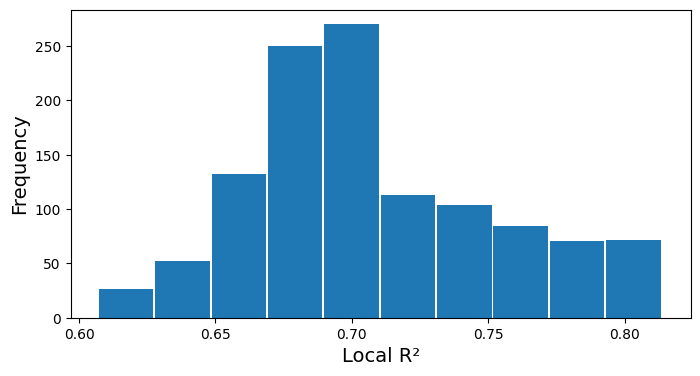

In [33]:
f,ax=plt.subplots(figsize=(8, 4))
ax.hist(gwr_fit.localR2, width=0.02);
ax.set_ylabel('Frequency', size=14);
ax.set_xlabel('Local R²', size=14);

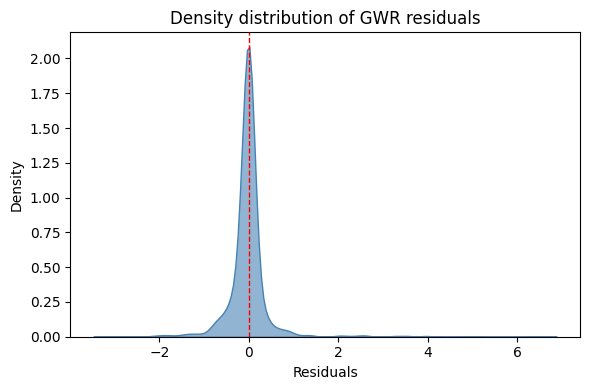

In [41]:
import seaborn as sns  # optional, for nicer aesthetics
import numpy as np

# Get residuals
residuals = gwr_fit.resid_response  # numpy array of residuals

# Plot kernel density
plt.figure(figsize=(6,4))
sns.kdeplot(residuals, fill=True, color="steelblue", alpha=0.6)
plt.axvline(0, color='red', linestyle='--', lw=1)
plt.title("Density distribution of GWR residuals")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

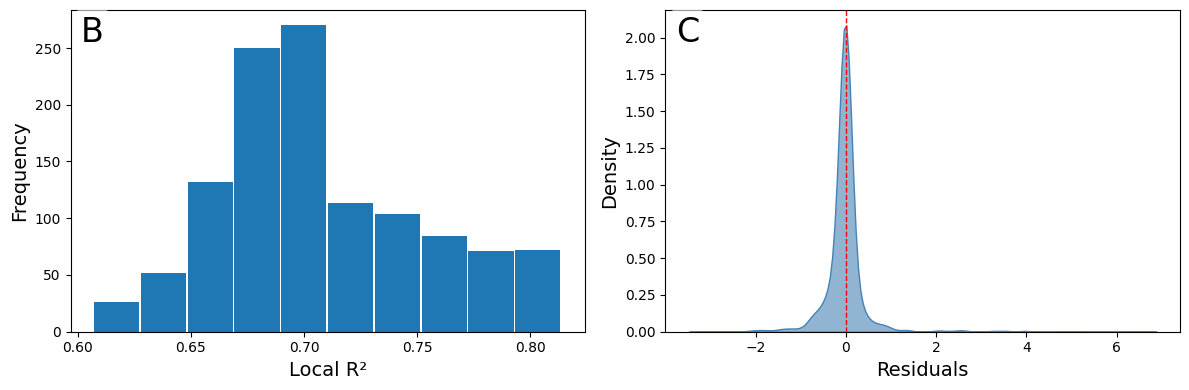

In [56]:
f,axs=plt.subplots(1,2, figsize=(12, 4))
ax=axs[0]
ax.hist(gwr_fit.localR2, width=0.02);
ax.text(
    0.02, 0.98,                      # (x, y) position in axes fraction (0–1)
    "B",           # your text
    transform=ax.transAxes,          # interpret coords in axes space, not data
    fontsize=24,
    color='black',
    ha='left', va='top',             # align relative to position
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
)

ax.set_ylabel('Frequency', size=14);
ax.set_xlabel('Local R²', size=14);
ax=axs[1]

residuals = gwr_fit.resid_response  # numpy array of residuals

# Plot kernel density
sns.kdeplot(residuals, fill=True, color="steelblue", alpha=0.6,ax=ax)
ax.text(
    0.02, 0.98,                      # (x, y) position in axes fraction (0–1)
    "C",           # your text
    transform=ax.transAxes,          # interpret coords in axes space, not data
    fontsize=24,
    color='black',
    ha='left', va='top',             # align relative to position
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
)
ax.axvline(0, color='red', linestyle='--', lw=1)
ax.set_xlabel("Residuals", size=14)
ax.set_ylabel("Density", size=14)
plt.tight_layout()


In [57]:
f.savefig('../Figures/Figure2BC.png', dpi=300, bbox_inches='tight')
f.savefig('../Figures/Figure2BC.pdf', dpi=300, bbox_inches='tight')

In [63]:
# 1) Local coefficients (betas) and local R2
coef_cols = ['Intercept'] + covariates
betas_df = pd.DataFrame(gwr_fit.params, columns=coef_cols)

gdfcrs_s = gdfcrs[['geometry']]
# 2) Join back to the GeoDataFrame (row-by-row alignment)
gdf_out = gdfcrs_s.reset_index(drop=True).join(betas_df, how="left")

In [98]:
# 1️⃣ Global OLS p-values from your table
ols_pvals = {
    "Forest": 0.021,
    "Shrub": 0.000,
    "Urban": 0.007,
    "Crop": 0.000,
    "Water": 0.098,
    "Other": 0.903,
    "Mean_P_Winter": 0.002,
    "Max_WD_Winter": 0.268,
    "Max_DD_Winter": 0.000,
    "Mean_T_Spring": 0.000,
    "Max_DD_Spring": 0.000,
    "Mean_T_Summer": 0.000,
    "Max_WD_Autumn": 0.689,
    "Max_DD_Autumn": 0.724,
    "gdp": 0.138,
    "pop_dens": 0.174
}

# 2️⃣ Select significant variables from the global model
sig_covars = [k for k, p in ols_pvals.items() if p < 0.05]
print("Significant predictors from OLS:", sig_covars)


Significant predictors from OLS: ['Forest', 'Shrub', 'Urban', 'Crop', 'Mean_P_Winter', 'Max_DD_Winter', 'Mean_T_Spring', 'Max_DD_Spring', 'Mean_T_Summer']


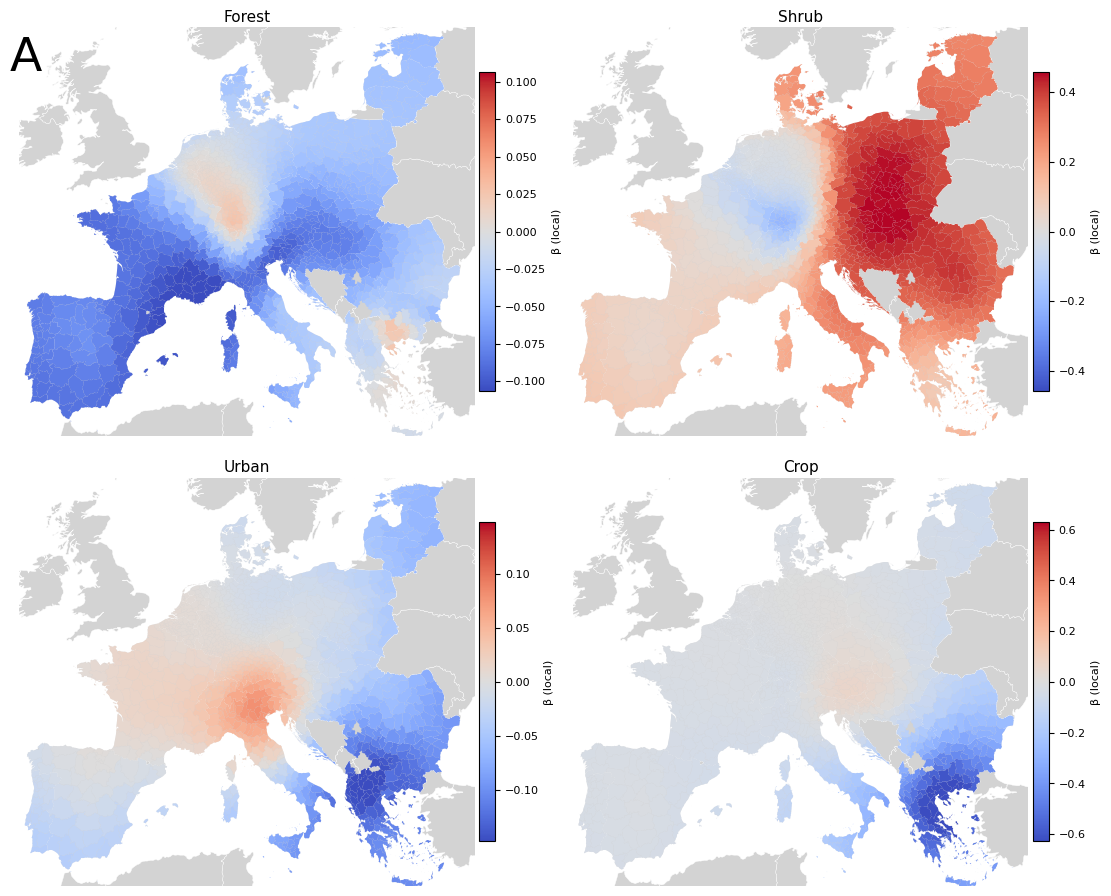

In [134]:
# --- choose the four land-cover covariates ---
sig_covars = ['Forest','Shrub','Urban','Crop']
cmap = 'coolwarm'   # diverging for signed coefficients
gdf_map = gdf_out       # or gdfcrs if that's your plotting GeoDataFrame

def plot_coef_map(ax, colname):
    # robust symmetric limits for THIS variable
    vals = gdf_map[colname].to_numpy()
    vals = vals[np.isfinite(vals)]
    v = np.nanpercentile(np.abs(vals), 99) if vals.size else 1.0
    v = 1e-6 if v == 0 else v
    vmin, vmax = -v, v

    # basemap + layer
    world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=0, transform=proj)
    gdf_map.plot(
        ax=ax, column=colname, cmap=cmap,
        vmin=vmin, vmax=vmax,
        linewidth=0.05, edgecolor='none', zorder=1
    )

    # cosmetics
    ax.set_title(colname, fontsize=11, pad=4)
    ax.set_axis_off()
    ax.set_xlim(-10, 31); ax.set_ylim(35, 60)

    # compact colorbar for this subplot
    im = ax.collections[-1]
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.01)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('β (local)', fontsize=8)

# --- figure layout: 2×2 ---
fig, axes = plt.subplots(
    2, 2, figsize=(11, 9),
    subplot_kw={'projection': proj},
    constrained_layout=True
)
c=0
for ax, col in zip(axes.ravel(), sig_covars):
    if c==0:
        ax.text(
            -0.02, 0.98,                      # (x, y) position in axes fraction (0–1)
            "A",           # your text
            transform=ax.transAxes,          # interpret coords in axes space, not data
            fontsize=34,
            color='black',
            ha='left', va='top',             # align relative to position
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
        )
    c+=1
    plot_coef_map(ax, col)

#fig.suptitle('GWR local coefficients — Land cover (OLS significant)', fontsize=14, y=0.995)
plt.show()

In [135]:
fig.savefig('../Figures/FIgure3.png', dpi=300, bbox_inches='tight')
fig.savefig('../Figures/FIgure3.pdf', dpi=300, bbox_inches='tight')

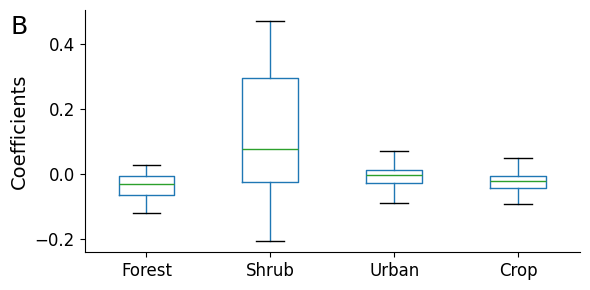

In [141]:
df = gdf_map[sig_covars]
# Boxplot without outliers
f, ax = plt.subplots(figsize=(6, 3))
df.boxplot(showfliers=False, ax=ax)
ax.text(
    -0.15, 0.98,                      # (x, y) position in axes fraction (0–1)
    "B",           # your text
    transform=ax.transAxes,          # interpret coords in axes space, not data
    fontsize=18,
    color='black',
    ha='left', va='top',             # align relative to position
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
)
# Axis label
ax.set_ylabel('Coefficients', fontsize=14)

# Remove grid
ax.grid(False)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: make bottom and left spines thinner and cleaner
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Optional: adjust tick label size
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()


In [142]:
f.savefig('../Figures/FIgure3bottom.png', dpi=300, bbox_inches='tight')
f.savefig('../Figures/FIgure3bottom.pdf', dpi=300, bbox_inches='tight')

Q:\UserTemp\massaro\AppData\Local\Temp\284\ipykernel_67960\832106911.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax_box.boxplot(


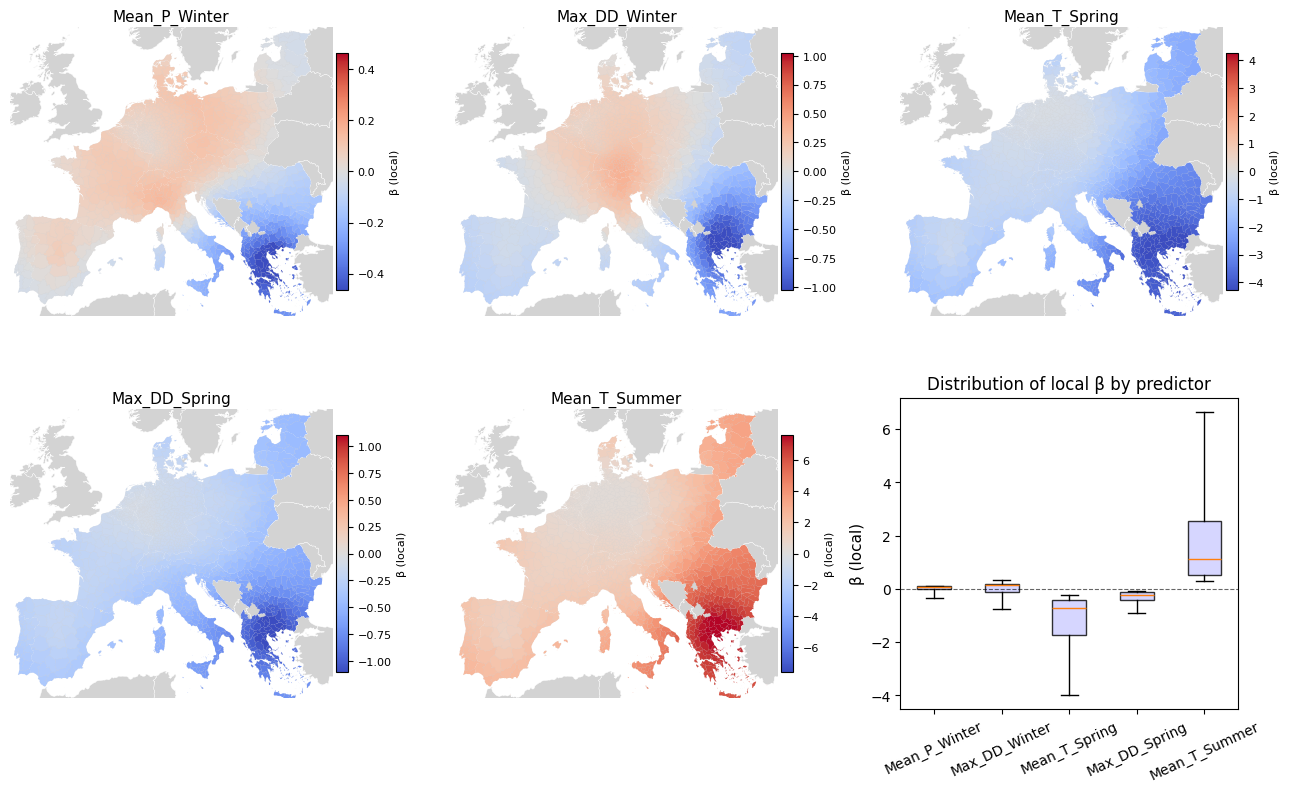

In [144]:
gdf_map = gdf_out   # or gdfcrs if that's your projected one used for plotting
sig_covars = ['Mean_P_Winter','Max_DD_Winter','Mean_T_Spring','Max_DD_Spring','Mean_T_Summer']
cmap = 'coolwarm'   # diverging for signed betas

def plot_coef_map(ax, colname):
    # symmetric color scale (robust to outliers)
    vals = gdf_map[colname].to_numpy()
    vals = vals[np.isfinite(vals)]
    v = np.nanpercentile(np.abs(vals), 99) if len(vals) > 0 else 1.0
    v = 1e-6 if v == 0 else v
    vmin, vmax = -v, v

    world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=0, transform=proj)
    gdf_map.plot(
        ax=ax, column=colname, cmap=cmap,
        vmin=vmin, vmax=vmax,
        linewidth=0.05, edgecolor='none', zorder=1
    )

    ax.set_title(colname, fontsize=11, pad=4)
    ax.set_axis_off()
    ax.set_xlim(-10, 31)
    ax.set_ylim(35, 60)

    # compact colorbar
    im = ax.collections[-1]
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.01)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('β (local)', fontsize=8)


# ---- FIGURE LAYOUT: 2×3 (5 maps + 1 boxplot) ----
fig = plt.figure(figsize=(13, 9))
gs = GridSpec(2, 3, height_ratios=[1, 0.6], figure=fig)

# Top row: first 3 climate maps
for i, col in enumerate(sig_covars[:3]):
    ax = plt.subplot(gs[0, i], projection=proj)
    plot_coef_map(ax, col)

# Bottom row: last 2 maps + boxplot
for i, col in enumerate(sig_covars[3:5]):
    ax = plt.subplot(gs[1, i], projection=proj)
    plot_coef_map(ax, col)

# Boxplot in the last cell
ax_box = plt.subplot(gs[1, 2])
box_data = [gdf_map[c].dropna().to_numpy() for c in sig_covars]
bp = ax_box.boxplot(
    box_data, labels=sig_covars, vert=True, patch_artist=True,
    showfliers=False, whis=[5, 95]
)
for patch in bp['boxes']:
    patch.set_facecolor('#ccccff')
    patch.set_alpha(0.8)
ax_box.axhline(0, color='k', lw=0.8, linestyle='--', alpha=0.6)
ax_box.set_ylabel('β (local)', fontsize=11)
ax_box.set_title('Distribution of local β by predictor', fontsize=12, pad=6)
ax_box.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [145]:
fig.savefig('../Figures/FIgure4.png', dpi=300, bbox_inches='tight')
fig.savefig('../Figures/FIgure4.pdf', dpi=300, bbox_inches='tight')

In [106]:
from matplotlib.gridspec import GridSpec

# ---- SETTINGS ----
gdf_map = gdf_out  # or gdfcrs if that's your projected one used for plotting
sig_covars = ['Forest','Shrub','Urban','Crop','Mean_P_Winter','Max_DD_Winter','Mean_T_Spring','Max_DD_Spring','Mean_T_Summer']
cmap = 'coolwarm'  # diverging for signed betas

# helper to plot one coefficient map with a compact colorbar
def plot_coef_map(ax, colname):
    # symmetric color scale per variable (robust to outliers)
    vals = gdf_map[colname].to_numpy()
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        v = 1.0
    else:
        v = np.nanpercentile(np.abs(vals), 99)  # robust symmetric limit
        v = 1e-6 if v == 0 else v
    vmin, vmax = -v, v

    world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=0, transform=proj)
    gdf_map.plot(
        ax=ax, column=colname, cmap=cmap,
        vmin=vmin, vmax=vmax, linewidth=0.05, edgecolor='none', zorder=1
    )
    ax.set_title(colname, fontsize=10, pad=4)
    ax.set_axis_off()
    ax.set_xlim(-10, 31); ax.set_ylim(35, 60)

    # tiny colorbar for this axis
    im = ax.collections[-1]
    cbar = plt.colorbar(im, ax=ax, fraction=0.030, pad=0.01)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('β (local)', fontsize=8)

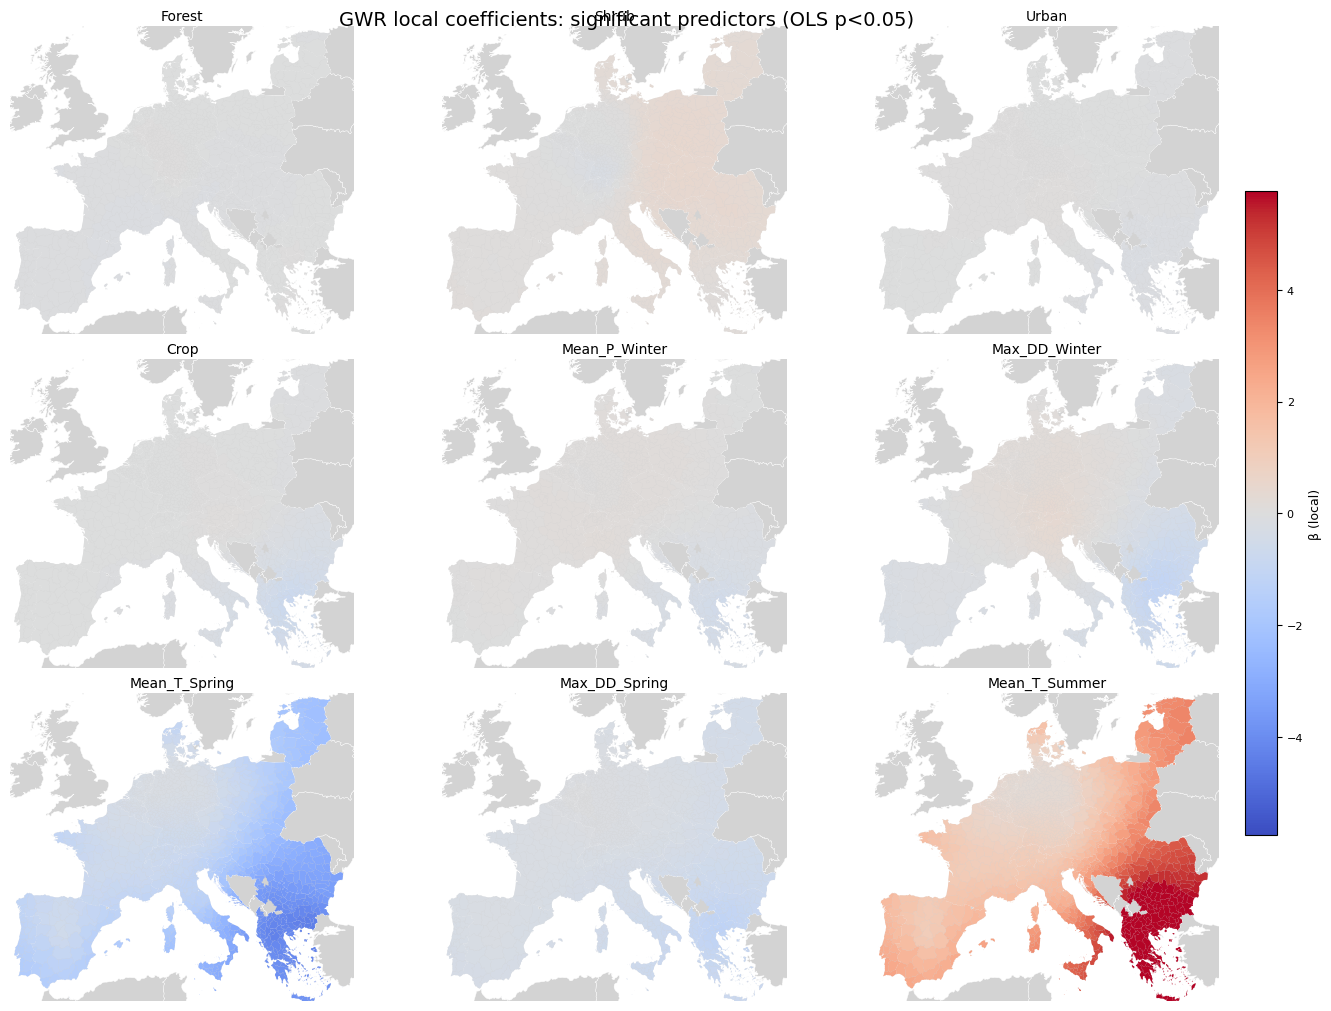

In [107]:
from matplotlib.colors import Normalize

# ---- GLOBAL symmetric color scale across all 9 betas (robust to outliers) ----
vals = gdf_map[sig_covars].to_numpy().astype(float)
V = np.nanpercentile(np.abs(vals), 99)  # change to 95 if you want stronger clipping
V = V if V > 0 else 1e-6
norm = Normalize(vmin=-V, vmax=V)

# ---- helper to plot one coefficient map (no per-axis colorbar) ----
def plot_coef_map(ax, colname):
    world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3, zorder=0, transform=proj)
    gdf_map.plot(
        ax=ax, column=colname, cmap=cmap,
        vmin=-V, vmax=V, linewidth=0.05, edgecolor='none', zorder=1
    )
    ax.set_title(colname, fontsize=10, pad=4)
    ax.set_axis_off()
    ax.set_xlim(-10, 31); ax.set_ylim(35, 60)

# ---- FIGURE LAYOUT: 3×3 ----
fig, axes = plt.subplots(3, 3, figsize=(14, 10), subplot_kw={'projection': proj}, constrained_layout=True)
axes = axes.ravel()

for ax, col in zip(axes, sig_covars):
    plot_coef_map(ax, col)

# shared colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.025, pad=0.02)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('β (local)', fontsize=9)

fig.suptitle('GWR local coefficients: significant predictors (OLS p<0.05)', fontsize=14, y=0.995)
plt.show()

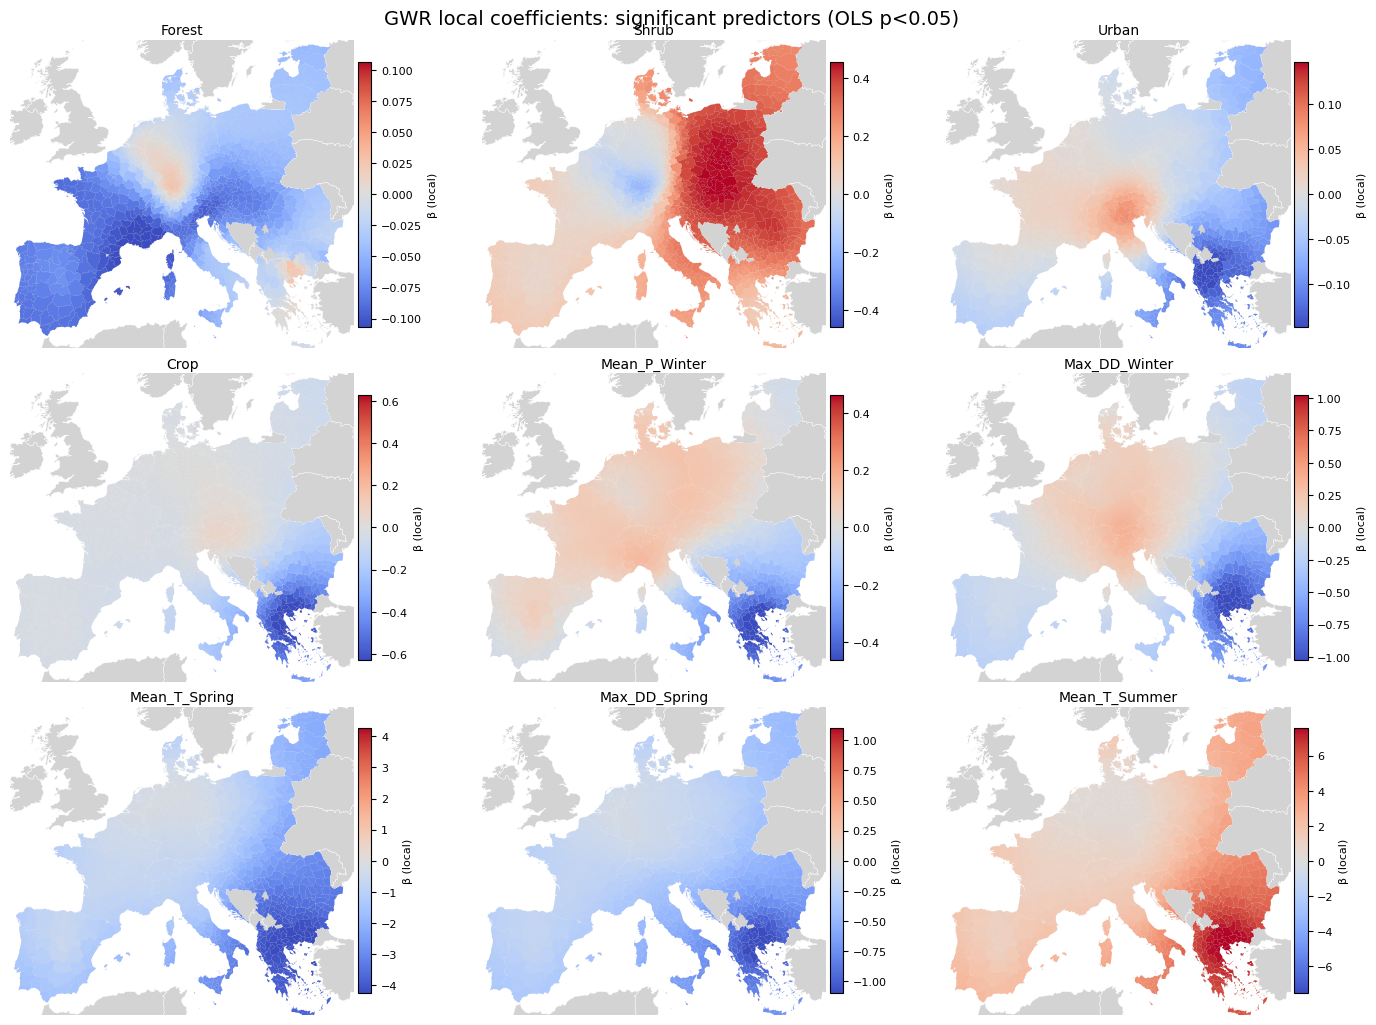

In [109]:
def plot_coef_map(ax, colname):
    # symmetric color scale (robust to outliers)
    vals = gdf_map[colname].to_numpy()
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        v = 1.0
    else:
        v = np.nanpercentile(np.abs(vals), 99)  # robust symmetric limit
        v = 1e-6 if v == 0 else v
    vmin, vmax = -v, v

    world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3,
               zorder=0, transform=proj)
    gdf_map.plot(
        ax=ax, column=colname, cmap=cmap,
        vmin=vmin, vmax=vmax,
        linewidth=0.05, edgecolor='none', zorder=1
    )

    ax.set_title(colname, fontsize=10, pad=4)
    ax.set_axis_off()
    ax.set_xlim(-10, 31)
    ax.set_ylim(35, 60)

    # add compact colorbar for each subplot
    im = ax.collections[-1]
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.01)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('β (local)', fontsize=8)

# ---- FIGURE LAYOUT: 3×3 grid ----
fig, axes = plt.subplots(
    3, 3, figsize=(14, 10),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

axes = axes.ravel()

for ax, col in zip(axes, sig_covars):
    plot_coef_map(ax, col)

#fig.suptitle('GWR local coefficients: significant predictors (OLS p<0.05)', fontsize=14, y=1.01)

plt.show()

In [94]:
gdf_out.columns

Index(['geometry', 'Intercept', 'Forest', 'Shrub', 'Urban', 'Crop', 'Water',
       'Other', 'Mean_P_Winter', 'Max_WD_Winter', 'Max_DD_Winter',
       'Mean_T_Spring', 'Max_DD_Spring', 'Mean_T_Summer', 'Max_WD_Autumn',
       'Max_DD_Autumn', 'gdp', 'pop_dens'],
      dtype='object')

<Axes: >

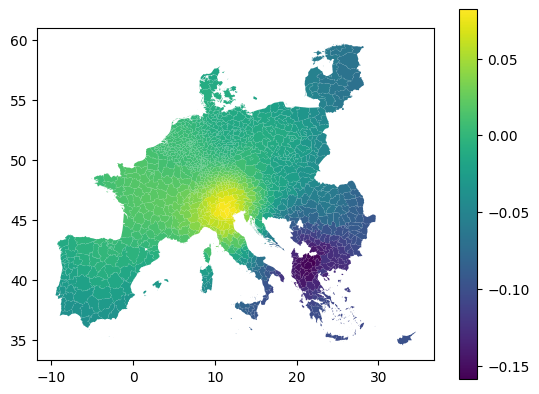

In [97]:
gdf_out.plot(column="Urban", legend=True)


In [71]:

# Collect local betas and t-values into DataFrames (aligned with gdf rows)
betas = pd.DataFrame(gwr_fit.params, columns=coef_cols)
tvals = pd.DataFrame(gwr_fit.tvalues, columns=coef_cols)
crit_t = 2.661

# 1) Mask non-significant betas as NaN
abs_B_sig = B.abs().where(T.abs() >= crit_t, np.nan)

# 2) Identify rows with at least one significant covariate
has_sig = ~abs_B_sig.isna().all(axis=1)

# 3) For rows that have any significant covariate:
#    - get the winning column (largest |beta|)
#    - map column names to integer indices
winner_col = pd.Series(index=abs_B_sig.index, dtype="object")
winner_col.loc[has_sig] = abs_B_sig.loc[has_sig].idxmax(axis=1)

col_to_idx = {c: i for i, c in enumerate(B.columns)}
col_idx = winner_col.map(col_to_idx)  # will be NaN where no winner

# 4) Extract the signed beta for the winner, safely
betas_np = B.to_numpy()
top_sig_beta = np.zeros(len(B), dtype=float)

valid = col_idx.notna().to_numpy()
col_idx_int = col_idx[valid].astype(int).to_numpy()
row_idx_int = np.nonzero(valid)[0]

top_sig_beta[valid] = betas_np[row_idx_int, col_idx_int]

# 5) Also keep the absolute value and the winner name
top_sig_abs = np.zeros(len(B), dtype=float)
top_sig_abs[valid] = abs_B_sig.to_numpy()[row_idx_int, col_idx_int]

top_sig_var = pd.Series("None", index=B.index, dtype="object")
top_sig_var[valid] = winner_col[valid].to_numpy()

In [73]:
gdf_out1 = gdf_out.reset_index(drop=True).assign(
    top_sig_var=top_sig_var.astype("category"),
    top_sig_abs=top_sig_abs,
    top_sig_beta=top_sig_beta
)

<Axes: >

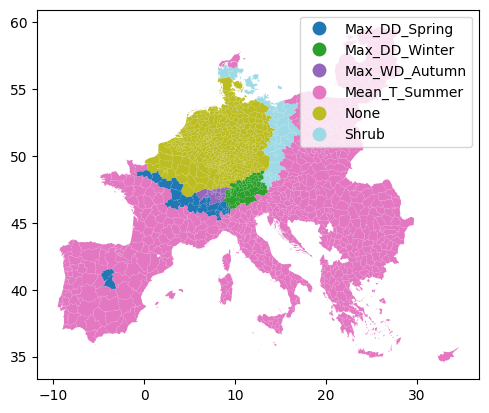

In [76]:
gdf_out1.plot(column="top_sig_var", categorical=True, cmap="tab20", legend=True)


In [78]:
from scipy.stats import t

df_resid = gwr_fit.df_resid  # degrees of freedom for residuals
P = 2 * (1 - t.cdf(np.abs(T), df=df_resid))

# Now you can use p-values directly:
p_threshold = 0.05  # significance level

# Mask non-significant betas as NaN
abs_B_sig = B.abs().where(P < p_threshold, np.nan)

# Identify rows with at least one significant covariate
has_sig = ~abs_B_sig.isna().all(axis=1)

# For each NUTS: find the covariate with the largest |β| among significant ones
winner_col = pd.Series(index=abs_B_sig.index, dtype="object")
winner_col.loc[has_sig] = abs_B_sig.loc[has_sig].idxmax(axis=1)

# Map column names to numeric indices
col_to_idx = {c: i for i, c in enumerate(B.columns)}
col_idx = winner_col.map(col_to_idx)

# Extract the corresponding *signed* β for each NUTS
betas_np = B.to_numpy()
top_sig_beta = np.zeros(len(B))
valid = col_idx.notna().to_numpy()
col_idx_int = col_idx[valid].astype(int).to_numpy()
row_idx_int = np.nonzero(valid)[0]
top_sig_beta[valid] = betas_np[row_idx_int, col_idx_int]

# Also store the absolute value and variable name
top_sig_abs = np.zeros(len(B))
top_sig_abs[valid] = abs_B_sig.to_numpy()[row_idx_int, col_idx_int]

top_sig_var = pd.Series("None", index=B.index, dtype="object")
top_sig_var[valid] = winner_col[valid].to_numpy()


In [79]:
gdf_out2 = gdf_out.reset_index(drop=True).assign(
    top_sig_var=top_sig_var.astype("category"),
    top_sig_abs=top_sig_abs,
    top_sig_beta=top_sig_beta
)

<Axes: >

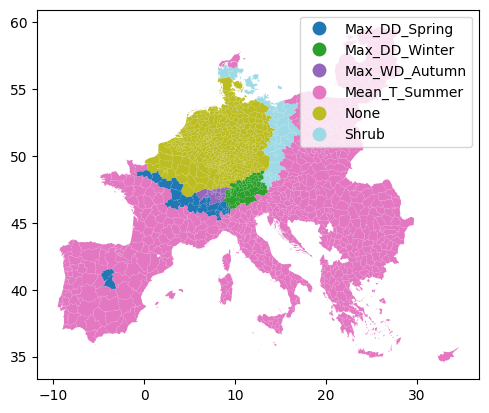

In [80]:
gdf_out1.plot(column="top_sig_var", categorical=True, cmap="tab20", legend=True)


In [82]:
# 1️⃣ Global OLS p-values from your table
ols_pvals = {
    "Forest": 0.021,
    "Shrub": 0.000,
    "Urban": 0.007,
    "Crop": 0.000,
    "Water": 0.098,
    "Other": 0.903,
    "Mean_P_Winter": 0.002,
    "Max_WD_Winter": 0.268,
    "Max_DD_Winter": 0.000,
    "Mean_T_Spring": 0.000,
    "Max_DD_Spring": 0.000,
    "Mean_T_Summer": 0.000,
    "Max_WD_Autumn": 0.689,
    "Max_DD_Autumn": 0.724,
    "gdp": 0.138,
    "pop_dens": 0.174
}

# 2️⃣ Select significant variables from the global model
sig_covars = [k for k, p in ols_pvals.items() if p < 0.05]
print("Significant predictors from OLS:", sig_covars)

# Example output:
# ['Forest', 'Shrub', 'Urban', 'Crop', 'Mean_P_Winter', 'Max_DD_Winter',
#  'Mean_T_Spring', 'Max_DD_Spring', 'Mean_T_Summer']

# 3️⃣ Extract local GWR coefficients for only those covariates
B = pd.DataFrame(gwr_fit.params, columns=["Intercept"] + list(ols_pvals.keys()))
B = B[sig_covars]  # keep only significant ones

# 4️⃣ For each NUTS, find the covariate with largest |beta|
abs_B = B.abs()
top_sig_var = abs_B.idxmax(axis=1)       # variable name
top_sig_abs = abs_B.max(axis=1)          # magnitude (abs value)
row_idx = np.arange(len(B))
col_idx = top_sig_var.map({c: i for i, c in enumerate(B.columns)}).to_numpy()
top_sig_beta = np.take_along_axis(B.to_numpy(), col_idx[:, None], axis=1).ravel()

Significant predictors from OLS: ['Forest', 'Shrub', 'Urban', 'Crop', 'Mean_P_Winter', 'Max_DD_Winter', 'Mean_T_Spring', 'Max_DD_Spring', 'Mean_T_Summer']


In [83]:
# 5️⃣ Attach results to your GeoDataFrame
gdf_out3 = gdf_out.reset_index(drop=True).assign(
    top_sig_var=top_sig_var.astype("category"),
    top_sig_abs=top_sig_abs,
    top_sig_beta=top_sig_beta
)

<Axes: >

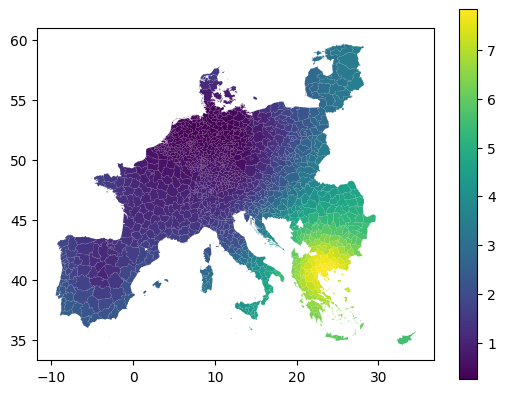

In [93]:
gdf_out3.plot(column="top_sig_beta", legend=True)
